# TFM — 05. Interpretabilidad: factores de riesgo para prevención vial (Pregunta 2)
**Autora:** Meritxell Abellan Collado

En este notebook respondo a la Pregunta 2 del TFM: *¿qué factores se asocian con una mayor gravedad, para informar campañas de prevención vial dirigidas?*

Uso el **modelo de referencia** ya entrenado y guardado en `04_Modelizacion.ipynb` (todas las variables, incluido el perfil de las personas implicadas) — no el modelo operativo, porque aquí el objetivo no es predecir en tiempo real sino entender qué pesa más en el riesgo de gravedad, y el modelo de referencia captura más señal (ver comparación Sección 3 de `04_Modelizacion.ipynb`).

Uso **SHAP (SHapley Additive exPlanations)** para descomponer cada predicción en la contribución de cada variable, con dos niveles de lectura:
- **Global:** ¿qué variables son las más importantes en conjunto? (bar plot de |SHAP| medio, beeswarm plot)
- **Focalizado:** ¿cómo varía el riesgo según distrito, franja horaria y edad? — las tres dimensiones de focalización que planteé como objetivo práctico del TFM.


## 0. Carga del modelo de referencia y de los datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap

import sys
sys.path.append('..')
from src.config import cfg

pd.set_option('display.max_columns', 60)
RANDOM_STATE = cfg.data['random_state']
PATH = str(cfg.ruta(cfg.paths['data']['features_dir'])) + '/'

X_train_ref = pd.read_csv(PATH + 'X_train_referencia.csv')
X_test_ref = pd.read_csv(PATH + 'X_test_referencia.csv')
y_train = pd.read_csv(PATH + 'y_train.csv').squeeze()
y_test = pd.read_csv(PATH + 'y_test.csv').squeeze()

modelo_referencia = joblib.load(str(cfg.ruta(cfg.paths['models_dir']) / cfg.model['produccion']['modelo_referencia']))

print(f'Modelo cargado: {type(modelo_referencia).__name__}')
print(f'Referencia — train: {X_train_ref.shape} | test: {X_test_ref.shape}')


Modelo cargado: HistGradientBoostingClassifier
Referencia — train: (58095, 43) | test: (10678, 43)


## 1. Cálculo de valores SHAP

Calculo los valores SHAP sobre `X_test_ref` (no sobre train, para que la explicación refleje cómo se comporta el modelo sobre datos que no ha visto, coherente con el resto del proyecto). Con ~10.678 filas de test, uso una muestra para que el cálculo sea manejable en tiempo razonable — `shap.Explainer` con un modelo basado en árboles (Gradient Boosting/Random Forest) es eficiente, pero aun así conviene acotar el tamaño de muestra para el cálculo exacto.


In [2]:
N_MUESTRA_SHAP = cfg.model['shap']['n_muestra']  # ajustar en config/model.yaml si el tiempo de cálculo lo permite

muestra_shap = X_test_ref.sample(n=min(N_MUESTRA_SHAP, len(X_test_ref)), random_state=RANDOM_STATE)

explainer = shap.Explainer(modelo_referencia, X_train_ref)
shap_values = explainer(muestra_shap, check_additivity=False)

print(f'Valores SHAP calculados sobre {len(muestra_shap):,} accidentes de test')


Background dataset has 58095 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=58095 when initializing the masker.


Valores SHAP calculados sobre 2,000 accidentes de test


### 1.1 Validación cruzada con regresión logística

Antes de interpretar el ranking SHAP, entreno un modelo de naturaleza completamente distinta -- una regresión logística -- sobre las mismas `X_train_ref`/`y_train`. Sus coeficientes los interpreto directamente como *odds ratios* (`exp(coeficiente)`), sin pasar por SHAP. Si dos modelos tan distintos (un ensemble de árboles vía SHAP, y un modelo lineal vía sus coeficientes) coinciden en qué variables dominan, eso refuerza que el hallazgo no es un artefacto de un algoritmo concreto, sino un patrón real en los datos.

In [3]:
from sklearn.linear_model import LogisticRegression
from src.utils.interpretabilidad import tabla_odds_ratios

logreg_ref = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE)
logreg_ref.fit(X_train_ref, y_train)

tabla_or = tabla_odds_ratios(logreg_ref, X_train_ref.columns, top_n=15)
tabla_or

,variable,coeficiente,odds_ratio
0,INCLUYE_MOTO,1.5439,4.68
1,ACC_ATROPELLO,1.1770,3.24
2,N_VICTIMAS_LOG,1.1444,3.14
3,PCT_HIST_MOTO_DISTRITO,-1.1391,0.32
4,ACC_VUELCO,1.1265,3.08
5,INCLUYE_BICI,1.1191,3.06
6,INCLUYE_PEATON,0.9937,2.70
7,ACC_CHOQUE CON OBJETO FIJO,0.9298,2.53
8,CPFA Niebla,-0.8528,0.43
9,ACC_OTRAS CAUSAS,0.6972,2.01


## 2. Importancia global de variables

**Bar plot:** ranking de variables por magnitud media absoluta de su contribución SHAP — cuánto pesa cada variable en promedio, sin importar si empuja el riesgo hacia arriba o hacia abajo.


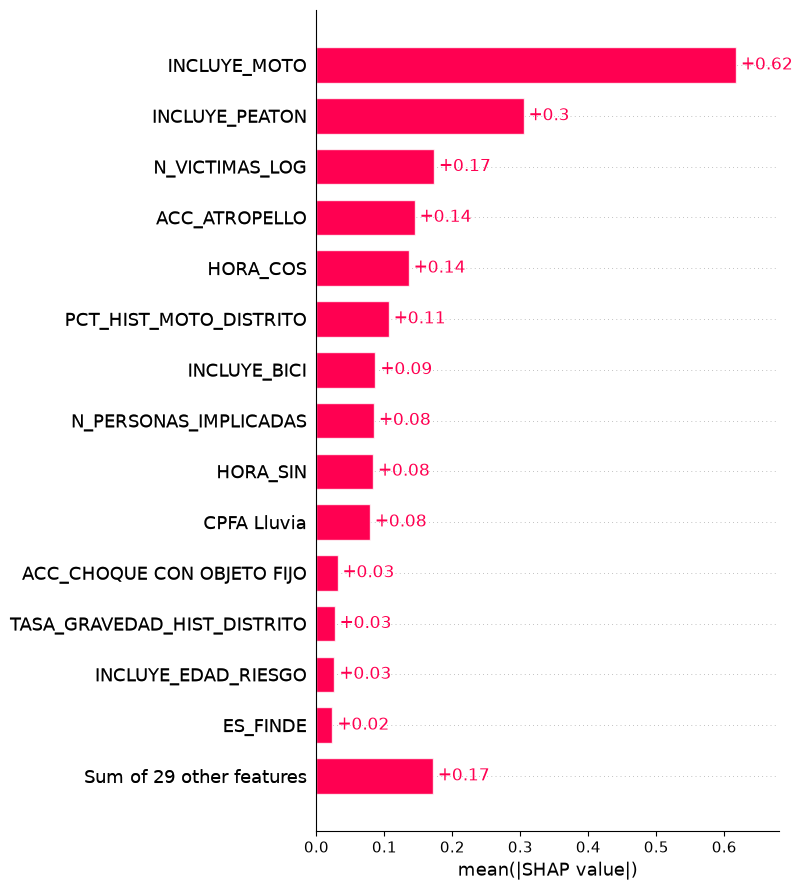

In [4]:
shap.plots.bar(shap_values, max_display=15, show=False)
plt.tight_layout()
plt.savefig('../figures/15_shap_importancia_global.png', dpi=150, bbox_inches='tight')
plt.show()


In [5]:
from src.utils.interpretabilidad import tabla_importancia_shap

tabla_shap = tabla_importancia_shap(shap_values, top_n=15)
tabla_shap

,variable,SHAP_log_odds,puntos_probabilidad_aprox
0,INCLUYE_MOTO,0.6173,15.26
1,INCLUYE_PEATON,0.3048,7.46
2,N_VICTIMAS_LOG,0.1730,4.20
3,ACC_ATROPELLO,0.1446,3.50
4,HORA_COS,0.1358,3.28
5,PCT_HIST_MOTO_DISTRITO,0.1065,2.57
6,INCLUYE_BICI,0.0868,2.09
7,N_PERSONAS_IMPLICADAS,0.0847,2.04
8,HORA_SIN,0.0833,2.00
9,CPFA Lluvia,0.0786,1.89


**INCLUYE_MOTO e INCLUYE_PEATON dominan**

INCLUYE_MOTO (contribución media |SHAP|=0.62, en escala log-odds) casi dobla al segundo puesto, y INCLUYE_PEATON (0.30) le sigue de cerca — juntas representan más peso que todas las demás variables combinadas (ver tabla anterior). Para dar una intuición de magnitud en términos de probabilidad (más fácil de comunicar que log-odds), la conversión debe partir del log-odds base que usa el propio explainer (`shap_values.base_values`), no de la tasa marginal simple (9,6%) — son distintos porque el modelo se entrena con `class_weight='balanced'`. Con la base real: +0,62 en log-odds equivale a ~15 puntos porcentuales de probabilidad, y +0,30 a ~7 puntos (ver columna `puntos_probabilidad_aprox` de la tabla anterior). Estas cifras son solo ilustrativas — el efecto real en puntos de probabilidad depende del resto de características del accidente concreto, debido a la no linealidad de la función sigmoide; el propio SHAP lo calculo y lo comparo siempre en la escala log-odds (aditiva), no en la de probabilidad.

Esto tiene mucho sentido desde el punto de vista de seguridad vial real: motoristas y peatones son, por naturaleza, los usuarios de la vía sin protección estructural (a diferencia de ir dentro de un coche), así que su implicación en un accidente predice gravedad de forma mucho más directa que casi cualquier otra variable de contexto.

**Confirmación cruzada con el modelo de regresión logística**

Este hallazgo no depende de un único modelo: los coeficientes de la regresión logística (Sección 1.1) confirman la misma jerarquía. `INCLUYE_MOTO` tiene el *odds ratio* más alto de todo el modelo (4,68) — la presencia de una moto multiplica por 4,7 las *odds* de que el accidente sea grave, manteniendo el resto de variables constantes — y `ACC_ATROPELLO` un *odds ratio* de 3,24, también entre los más altos. Que dos modelos de naturaleza muy distinta (un ensemble de árboles vía SHAP, y un modelo lineal vía sus coeficientes) coincidan en qué variables dominan refuerza que no es un artefacto de un algoritmo concreto, sino un patrón en los datos.

**Un matiz interesante: ACC_ATROPELLO vs. INCLUYE_PEATON**

`ACC_ATROPELLO` (0,14 en log-odds, ~3,5 puntos de probabilidad) pesa bastante menos que `INCLUYE_PEATON` (0,30, ~7 puntos), aunque un atropello implica un peatón casi por definición. Esto sugiere que `INCLUYE_PEATON` está capturando algo más amplio que solo los atropellos — probablemente también peatones heridos en otros tipos de accidente (p. ej., un peatón golpeado en una colisión múltiple que no se clasifica como "atropello" en `TIPO ACCIDENTE`). Es una observación útil para la memoria: el SHAP está separando dos señales que a primera vista parecían redundantes.

**El punto que hay que tratar con cautela: N_VICTIMAS_LOG en 3er puesto**

Esta es exactamente la variable sobre la que ya avisé en el EDA — recupero la nota de fuga de información que documenté allí: `GRAVE` se define como el máximo de lesividad entre los implicados, así que un accidente con más víctimas tiene, casi por construcción matemática, más probabilidad de que alguna sea grave. No es que "tener más víctimas cause gravedad" en un sentido causal útil para prevención — es en buena parte una relación mecánica del propio diseño del target. Para la memoria, esto hay que señalarlo explícitamente: su alta importancia aquí no debe leerse como un hallazgo de prevención accionable ("reducir el número de víctimas" no tiene sentido como recomendación, es al revés).

### Beeswarm plot

Cada punto es un accidente; el color indica el valor de la variable (rojo=alto, azul=bajo) y la posición horizontal indica si esa variable empujó la predicción hacia mayor gravedad (derecha) o menor (izquierda). Permite ver no solo qué variables importan, sino en qué dirección.


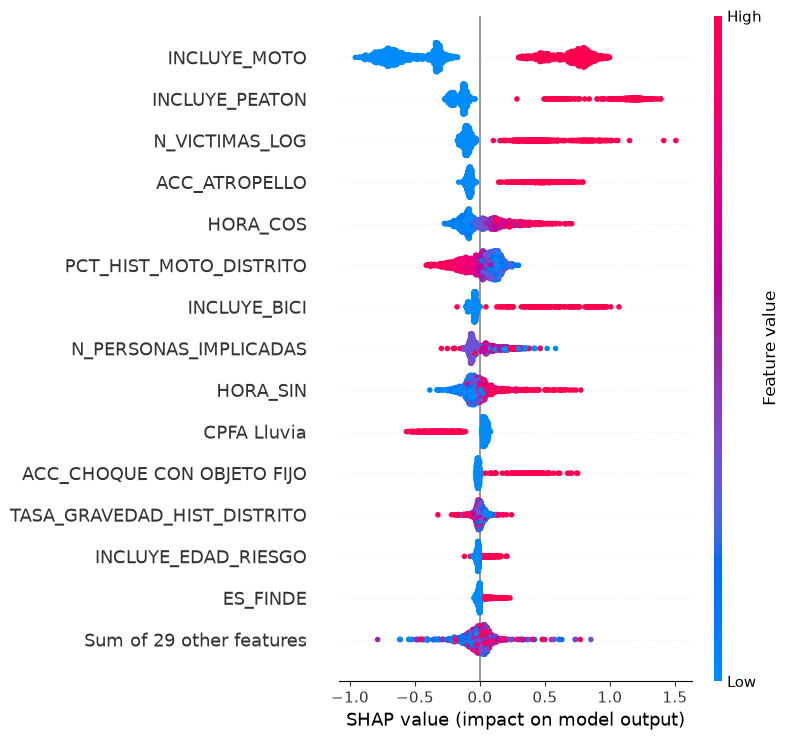

In [6]:
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.tight_layout()
plt.savefig('../figures/16_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:
# Verificación con datos: tasa de gravedad por nº de personas implicadas
# (agrupando 3+ por tamaño de muestra), citada en el párrafo anterior
from scipy.stats import mannwhitneyu, chi2_contingency

grupo_n_pers = X_train_ref['N_PERSONAS_IMPLICADAS'].apply(lambda x: str(int(x)) if x < 3 else '3+')
tasa_por_n_pers = (pd.DataFrame({'grupo': grupo_n_pers, 'GRAVE': y_train})
                   .groupby('grupo')['GRAVE'].agg(['mean', 'count'])
                   .rename(columns={'mean': 'pct_grave', 'count': 'n'}))
tasa_por_n_pers['pct_grave'] = (tasa_por_n_pers['pct_grave'] * 100).round(1)

_, p_mw = mannwhitneyu(X_train_ref['N_PERSONAS_IMPLICADAS'], y_train)
ct = pd.crosstab(grupo_n_pers, y_train)
chi2_val, p_chi2, _, expected = chi2_contingency(ct)

print(tasa_por_n_pers)
print(f"\nMann-Whitney U (N_PERSONAS_IMPLICADAS vs GRAVE): p={p_mw:.2e}")
print(f"Chi² (grupo vs GRAVE): chi2={chi2_val:.1f}, p={p_chi2:.2e}, "
      f"% celdas esperada<5: {(expected < 5).mean()*100:.1f}%")

       pct_grave      n
grupo                  
1            8.8   7618
2           10.7  29183
3+           9.0  21294

Mann-Whitney U (N_PERSONAS_IMPLICADAS vs GRAVE): p=0.00e+00
Chi² (grupo vs GRAVE): chi2=51.7, p=5.88e-12, % celdas esperada<5: 0.0%


El diagrama de dispersión SHAP (beeswarm) confirma y matiza los hallazgos del ranking de importancia global. Las tres variables relativas a usuarios vulnerables de la vía (INCLUYE_MOTO, INCLUYE_PEATON, INCLUYE_BICI) muestran el patrón más consistente del análisis: una separación limpia entre los casos en los que estos usuarios están presentes (en rojo, empujando la predicción hacia mayor gravedad, con un efecto medio de aproximadamente 7 y 3 puntos porcentuales de probabilidad para moto y peatón respectivamente) y los casos en los que no lo están (en azul, sin apenas efecto). 

La codificación cíclica de la hora (HORA_SIN, HORA_COS) reproduce, de forma independiente, el patrón horario ya observado en el análisis descriptivo por franja horaria: los valores asociados a la madrugada empujan sistemáticamente hacia mayor gravedad, mientras que las horas centrales del día lo hacen hacia menor gravedad — una coincidencia entre dos análisis distintos que refuerza la fiabilidad del hallazgo. 

El número de personas implicadas (N_PERSONAS_IMPLICADAS) muestra una relación con la gravedad más compleja que un simple efecto lineal: la tasa de gravedad no desciende de forma monótona con el número de implicados (tabla y tests en la celda siguiente). Este patrón no monótono podría reflejar mecanismos distintos según el tipo de siniestro — accidentes de un único implicado (p. ej. caídas de bicicleta o moto sin colisión) frente a colisiones entre dos partes, con posiblemente mayor energía de impacto — y merecería un análisis más detallado, cruzando esta variable con el tipo de accidente, antes de extraer una conclusión causal firme para prevención.

Observo además un patrón menos esperado: la presencia de lluvia (CPFA Lluvia) se asocia consistentemente con menor gravedad, un efecto contraintuitivo que podría explicarse por una reducción defensiva de la velocidad en condiciones meteorológicas adversas (mismo patrón ya documentado con datos descriptivos en `01_EDA.ipynb`, Sección 9). 

Variables como la tasa histórica de gravedad del distrito o el porcentaje histórico de motos por distrito, pese a figurar entre las más relevantes en magnitud media, no muestran una separación de color limpia — su contribución varía según el contexto del resto de variables, en lugar de tener un efecto propio y estable. Todas las magnitudes se expresan en escala log-odds (aditiva, la escala nativa de los valores SHAP); su traducción a puntos de probabilidad es solo aproximada, ya que depende de la no linealidad de la función sigmoide y del punto de partida de cada predicción.

## 3. Focalización por distrito, franja horaria y edad

Estas son las tres dimensiones de focalización planteadas como objetivo práctico del TFM (campañas de prevención dirigidas). Examino la contribución SHAP de las variables correspondientes a cada una.


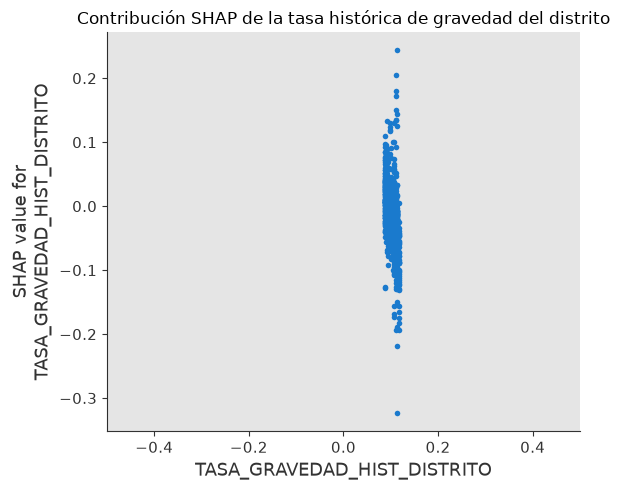

In [8]:
# Distrito: TASA_GRAVEDAD_HIST_DISTRITO — su valor SHAP indica cuánto pesa
# el historial de gravedad de cada distrito en la predicción de un accidente concreto
idx_distrito = list(muestra_shap.columns).index('TASA_GRAVEDAD_HIST_DISTRITO')
shap.plots.scatter(shap_values[:, idx_distrito], show=False)
plt.title('Contribución SHAP de la tasa histórica de gravedad del distrito')
plt.tight_layout()
plt.savefig('../figures/17_shap_distrito.png', dpi=150, bbox_inches='tight')
plt.show()


In [9]:
# Traduce el agregado histórico de vuelta al nombre real de distrito
# (solo válido sobre test, ver docstring de la función)
from src.pipelines.pipeline_produccion import PipelineAccidentes
from src.utils.interpretabilidad import tabla_shap_por_distrito

pipe = PipelineAccidentes.load(str(cfg.ruta(cfg.paths['models_dir']) / cfg.model['produccion']['pipeline']))
tabla_distrito = tabla_shap_por_distrito(shap_values, muestra_shap, pipe)
tabla_distrito

,DISTRITO,n,shap_medio,tasa_hist
0,SALAMANCA,168,0.0312,0.0901
1,CHAMARTIN,148,0.0264,0.0910
2,MONCLOA-ARAVACA,109,0.0153,0.0886
3,CIUDAD LINEAL,131,0.0133,0.0927
4,TETUAN,100,0.0112,0.0928
5,ARGANZUELA,108,0.0036,0.0973
6,RETIRO,110,0.0014,0.0963
7,CENTRO,148,0.0013,0.0974
8,BARAJAS,33,-0.0043,0.1003
9,USERA,72,-0.0056,0.0945


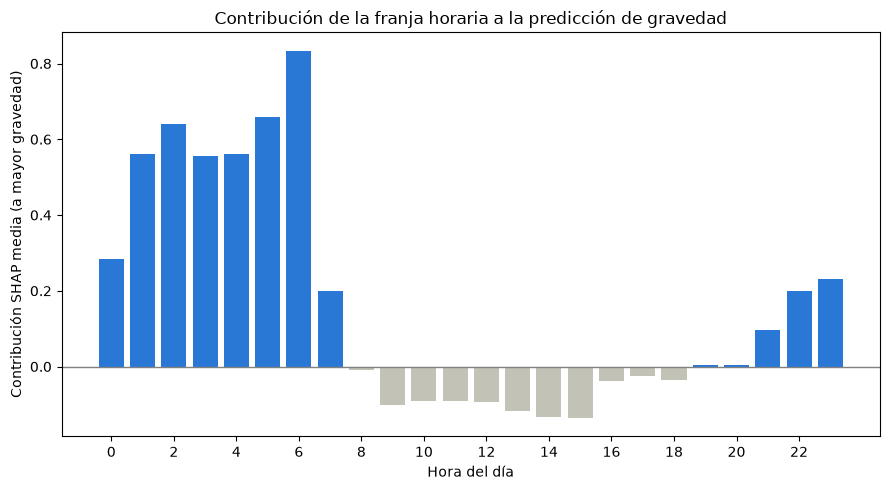

In [10]:
# Franja horaria: combinar la contribución de HORA_SIN y HORA_COS
# (la codificación cíclica reparte la señal horaria entre las dos columnas)
idx_hora_sin = list(muestra_shap.columns).index('HORA_SIN')
idx_hora_cos = list(muestra_shap.columns).index('HORA_COS')

contribucion_hora = shap_values.values[:, idx_hora_sin] + shap_values.values[:, idx_hora_cos]
hora_aprox = np.arctan2(muestra_shap['HORA_SIN'], muestra_shap['HORA_COS']) * 24 / (2 * np.pi)
hora_aprox = hora_aprox.where(hora_aprox >= 0, hora_aprox + 24).round().astype(int)

tabla_hora = pd.DataFrame({'HORA': hora_aprox, 'contribucion_shap': contribucion_hora})
resumen_hora = tabla_hora.groupby('HORA')['contribucion_shap'].mean().sort_index()

fig, ax = plt.subplots(figsize=(9, 5))
colores = ['#2a78d6' if v > 0 else '#c3c2b7' for v in resumen_hora]
ax.bar(resumen_hora.index, resumen_hora.values, color=colores)
ax.axhline(0, color='grey', linewidth=1)
ax.set_xlabel('Hora del día')
ax.set_ylabel('Contribución SHAP media (a mayor gravedad)')
ax.set_title('Contribución de la franja horaria a la predicción de gravedad')
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.savefig('../figures/18_shap_hora.png', dpi=150, bbox_inches='tight')
plt.show()


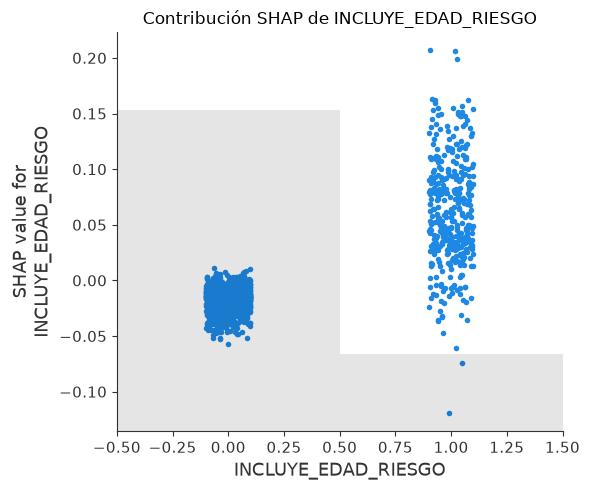

In [11]:
# Edad de riesgo: INCLUYE_EDAD_RIESGO
idx_edad = list(muestra_shap.columns).index('INCLUYE_EDAD_RIESGO')
shap.plots.scatter(shap_values[:, idx_edad], show=False)
plt.title('Contribución SHAP de INCLUYE_EDAD_RIESGO')
plt.tight_layout()
plt.savefig('../figures/19_shap_edad_riesgo.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Conclusiones para el diseño de campañas de prevención vial

> - **Geográfica:** la tabla de `tabla_shap_por_distrito` muestra que la contribución SHAP por distrito **no sigue el mismo orden que su tasa histórica bruta** (`tasa_hist`). Salamanca, Chamartín, Moncloa-Aravaca, Ciudad Lineal y Tetuán son los que más empujan la predicción hacia mayor gravedad (SHAP medio positivo) pese a tener una tasa histórica moderada (~0.09-0.09); mientras que Vicálvaro, Puente de Vallecas y San Blas, con tasa histórica más alta (~0.11-0.12), quedan con SHAP medio negativo — el modelo ya explica buena parte de su riesgo bruto a través de otras variables (tipo de accidente, vehículo), y lo que queda como contribución *incremental* propia del distrito es menor. Para focalizar campañas por el riesgo que el modelo no atribuye ya a otro factor, los distritos prioritarios son Salamanca/Chamartín/Moncloa-Aravaca, no los de mayor tasa bruta. Nota de cautela: el tamaño de muestra por distrito en esta muestra de test (33 a 168 accidentes) es limitado, así que esta priorización es directional, no definitiva.
> - **Temporal:** la franja horaria de madrugada (0h-7h, con pico en torno a las 6h) es, con diferencia, la que más empuja hacia mayor gravedad; a partir de las 9h y hasta media tarde el efecto es negativo, y vuelve a subir progresivamente desde las 21h. Esto sugiere concentrar recursos de respuesta rápida y campañas de concienciación (velocidad, alcohol, fatiga) en el tramo nocturno, coherente con lo ya observado de forma descriptiva en `01_EDA.ipynb`.
> - **Demográfica:** `INCLUYE_EDAD_RIESGO` muestra una separación limpia y consistente: cuando hay una persona de edad de riesgo (menor de edad o mayor de 65) implicada, la contribución SHAP es sistemáticamente positiva (típicamente +0.02 a +0.16 en log-odds); cuando no la hay, es ligeramente negativa y con mucha menos dispersión. Es un efecto más modesto en magnitud que `INCLUYE_MOTO`/`INCLUYE_PEATON`, pero consistente en dirección — apoya mantener campañas dirigidas a menores y mayores como una línea de prevención independiente, no redundante con el tipo de vehículo.
> - **En conjunto:** las variables con mayor poder predictivo (moto, peatón, tipo de atropello) no son accionables directamente por una campaña de prevención — no se puede "prohibir" que haya motoristas o peatones — pero sí informan **dónde y cuándo** reforzar la protección de esos usuarios vulnerables: las combinaciones de distrito, franja horaria y perfil de edad identificadas arriba son la traducción operativa de ese hallazgo para el diseño de campañas dirigidas.
